In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("salary_prediction2.csv")
df.head()

,Experience_Years,Age,Education_Level,Performance_Score,Salary
0,6,33,4,3.049288,84601
1,19,45,3,9.063182,143405
2,28,51,1,4.073961,139340
3,14,41,4,3.783769,116349
4,10,34,3,7.540805,102475


In [26]:
X = df.drop("Salary", axis=1)
y = df["Salary"]
X,y

(      Experience_Years  Age  Education_Level  Performance_Score
 0                    6   33                4           3.049288
 1                   19   45                3           9.063182
 2                   28   51                1           4.073961
 3                   14   41                4           3.783769
 4                   10   34                3           7.540805
 ...                ...  ...              ...                ...
 9995                12   37                1           9.973208
 9996                12   35                2           4.675417
 9997                16   41                4           2.640963
 9998                26   52                4           6.522457
 9999                 6   28                4           3.126589
 
 [10000 rows x 4 columns],
 0        84601
 1       143405
 2       139340
 3       116349
 4       102475
          ...  
 9995     91857
 9996     69168
 9997    120483
 9998    186307
 9999     66473
 Name: Salary, 

In [42]:
def run_lr(test_size):
    print(f"\n--- Split Ratio {int((1-test_size)*100)}:{int(test_size*100)} ---")

    # TRAIN-TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42 )

    # MODEL
    model = LinearRegression()

    # TRAIN & PREDICT
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # EVALUATION
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)

    return mse, rmse, mae, r2

results_lr = {}

results_lr["70:30"] = run_lr(0.3)
results_lr["60:40"] = run_lr(0.4)
results_lr["80:20"] = run_lr(0.2)


--- Split Ratio 70:30 ---
MSE: 98725810.49700756
RMSE: 9936.086276648748
MAE: 7940.565099943133
R2 Score: 0.9351744945667053

--- Split Ratio 60:40 ---
MSE: 98394276.61574945
RMSE: 9919.388923504786
MAE: 7919.532254918169
R2 Score: 0.9354255183953712

--- Split Ratio 80:20 ---
MSE: 100624263.56041974
RMSE: 10031.164616355358
MAE: 8021.939025442934
R2 Score: 0.9330135855666897


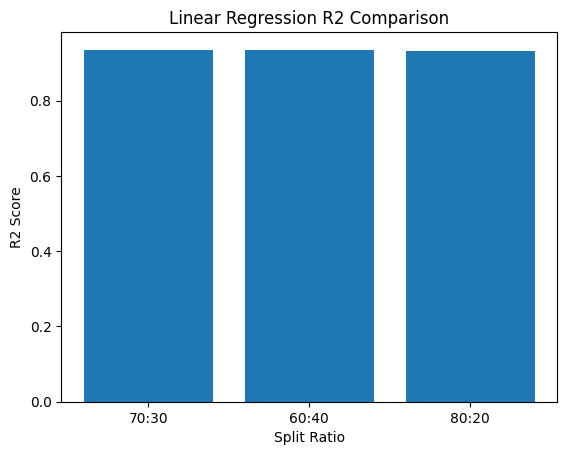

In [43]:
labels = list(results_lr.keys())
r2_scores = [results_lr[k][3] for k in labels]

plt.bar(labels, r2_scores)
plt.title("Linear Regression R2 Comparison")
plt.xlabel("Split Ratio")
plt.ylabel("R2 Score")
plt.show()

In [44]:
# COEFFICIENTS & INTERCEPT
for i, col in enumerate(X.columns):
    print(f"{col} Coefficient:", model.coef_[i])

print("Intercept:", model.intercept_)

Experience_Years Coefficient: 3983.787755680029
Age Coefficient: 13.676328262663844
Education_Level Coefficient: 8014.584687819803
Performance_Score Coefficient: 2993.8837218624753
Intercept: 19556.21181556629


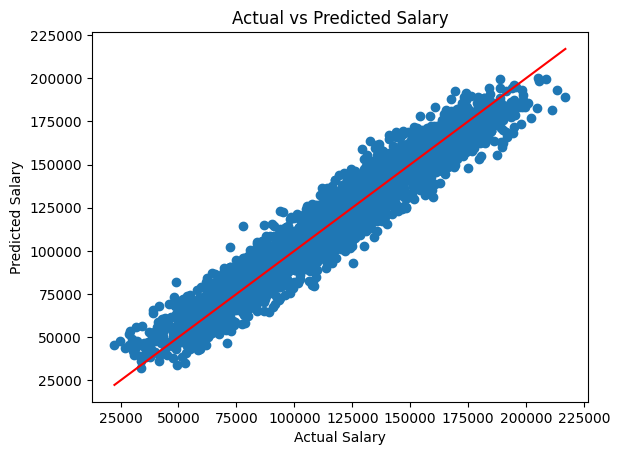

In [45]:
y_pred = model.predict(X_test)
plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],color='red')  

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [46]:
# NEW DATAPOINTS
new_data = [[25, 50, 5,4]]   
prediction = model.predict(new_data)

print("\nPredicted Salary:", prediction[0])


Predicted Salary: 171883.18044724912
